CS 4407 Data Mining and Machine Learning Applications
Unit 3 Programming Assignment
Classification Models for Flower Species Prediction
Danielle Walker
University of the People

1. Data Generation and Preparation

In [ ]:
# Import required Python libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import the Iris dataset
from sklearn.datasets import load_iris

# Import tools for splitting and preprocessing data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Import classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Import evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Load the Iris dataset
iris = load_iris()

# Separate features and target variable
X = iris.data
y = iris.target

# Create a DataFrame for easier viewing
iris_df = pd.DataFrame(X, columns=iris.feature_names)

# Add the flower species to the DataFrame
iris_df["species"] = [iris.target_names[value] for value in y]

# Display basic dataset information
print("Dataset shape:", X.shape)
print("\nFeature names:")
print(iris.feature_names)

print("\nTarget classes:")
print(iris.target_names)

print("\nClass distribution:")
print(iris_df["species"].value_counts())

print("\nFirst five rows:")
display(iris_df.head())

Dataset shape: (150, 4)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target classes:
['setosa' 'versicolor' 'virginica']

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

First five rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Split the dataset into 80% training data and 20% testing data
# stratify=y preserves the balanced class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class counts:")
print(np.bincount(y_train))

print("\nTesting class counts:")
print(np.bincount(y_test))

Training samples: 120
Testing samples: 30

Training class counts:
[40 40 40]

Testing class counts:
[10 10 10]


In [ ]:
# Dictionary used to store model results for final comparison
results = {}

def evaluate_model(model_name, y_true, y_pred):
    """
    Evaluate a classification model using accuracy,
    precision, recall, F1-score, and confusion matrix.
    """

    accuracy = accuracy_score(y_true, y_pred)

    # Macro averaging gives each flower species equal importance
    precision = precision_score(
        y_true, y_pred, average="macro", zero_division=0
    )

    recall = recall_score(
        y_true, y_pred, average="macro", zero_division=0
    )

    f1 = f1_score(
        y_true, y_pred, average="macro", zero_division=0
    )

    # Store results
    results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-Score:  {f1:.3f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=iris.target_names,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    # Display graphical confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=iris.target_names,
        cmap="Blues"
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

2A. Rule-Based and Probabilistic Models

Decision Tree

Decision Tree
Accuracy:  0.967
Precision: 0.970
Recall:    0.967
F1-Score:  0.967

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


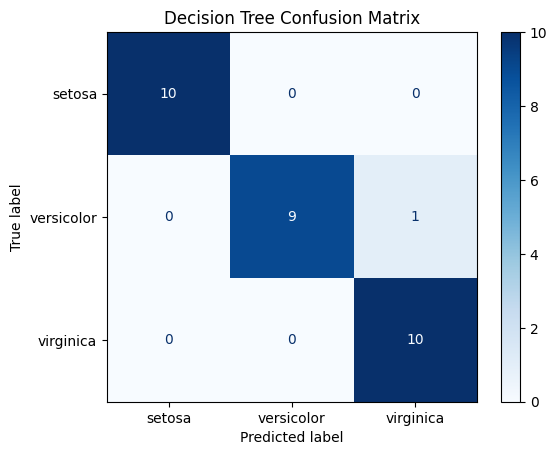

In [ ]:
# Build and train the Decision Tree classifier

decision_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

decision_tree.fit(X_train, y_train)

# Predict the test data
dt_predictions = decision_tree.predict(X_test)

# Evaluate the model
evaluate_model(
    "Decision Tree",
    y_test,
    dt_predictions
)

Rule-Based Classifier
Accuracy:  0.967
Precision: 0.970
Recall:    0.967
F1-Score:  0.967

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


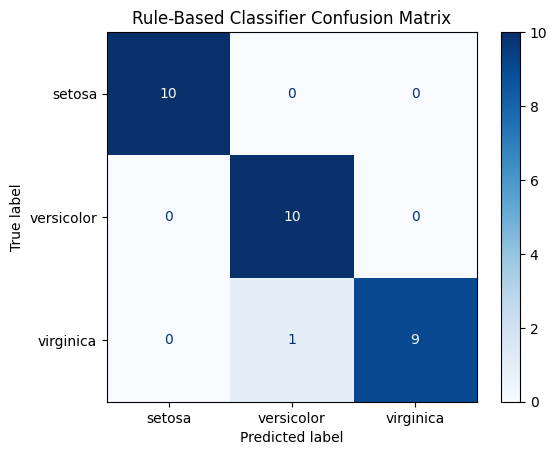

In [ ]:
# Custom rule-based classifier using simple if-else statements
# Column 2 is petal length and column 3 is petal width

def rule_based_classifier(data):
    predictions = []

    for flower in data:

        petal_length = flower[2]
        petal_width = flower[3]

        # Setosa generally has very short petals
        if petal_length < 2.5:
            predictions.append(0)

        # Versicolor generally has intermediate petal measurements
        elif petal_width < 1.75:
            predictions.append(1)

        # Larger petal measurements generally indicate Virginica
        else:
            predictions.append(2)

    return np.array(predictions)


# Make predictions using the rules
rule_predictions = rule_based_classifier(X_test)

# Evaluate the rule-based classifier
evaluate_model(
    "Rule-Based Classifier",
    y_test,
    rule_predictions
)

Naive Bayes
Accuracy:  0.967
Precision: 0.970
Recall:    0.967
F1-Score:  0.967

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


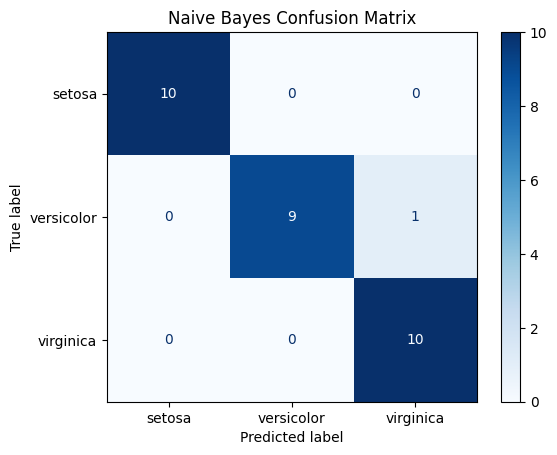

In [ ]:
# Build and train Gaussian Naive Bayes

naive_bayes = GaussianNB()

naive_bayes.fit(X_train, y_train)

nb_predictions = naive_bayes.predict(X_test)

evaluate_model(
    "Naive Bayes",
    y_test,
    nb_predictions
)

2B. Distance and Optimization-Based Models

Logistic Regression

Logistic Regression
Accuracy:  0.933
Precision: 0.933
Recall:    0.933
F1-Score:  0.933

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


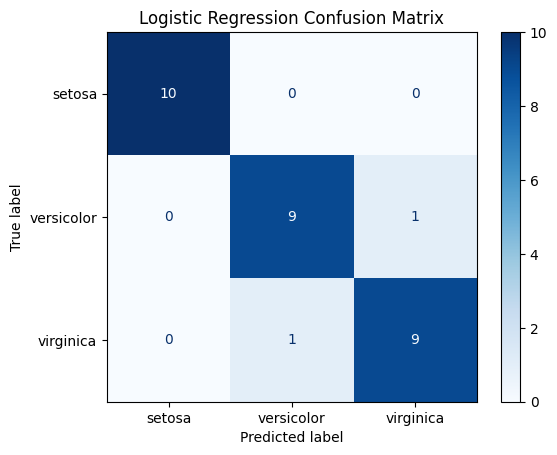

In [ ]:
# Build Logistic Regression using standardized features
# Scaling places features on comparable scales

logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        random_state=42
    )
)

logistic_model.fit(X_train, y_train)

lr_predictions = logistic_model.predict(X_test)

evaluate_model(
    "Logistic Regression",
    y_test,
    lr_predictions
)

K-Nearest Neighbors
Accuracy:  0.933
Precision: 0.944
Recall:    0.933
F1-Score:  0.933

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


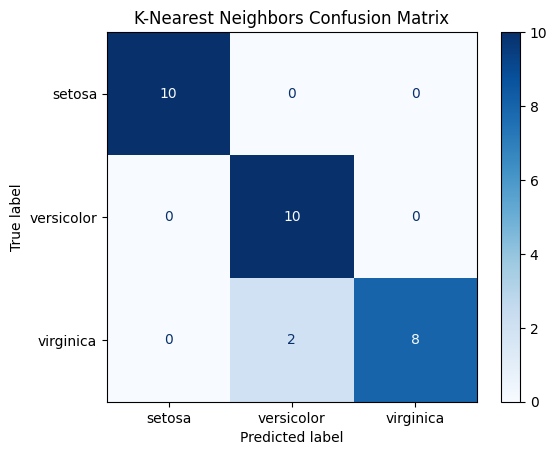

In [ ]:
# Build K-Nearest Neighbors classifier
# StandardScaler is important because KNN uses distances

knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)

evaluate_model(
    "K-Nearest Neighbors",
    y_test,
    knn_predictions
)

Support Vector Machine
Accuracy:  0.967
Precision: 0.970
Recall:    0.967
F1-Score:  0.967

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


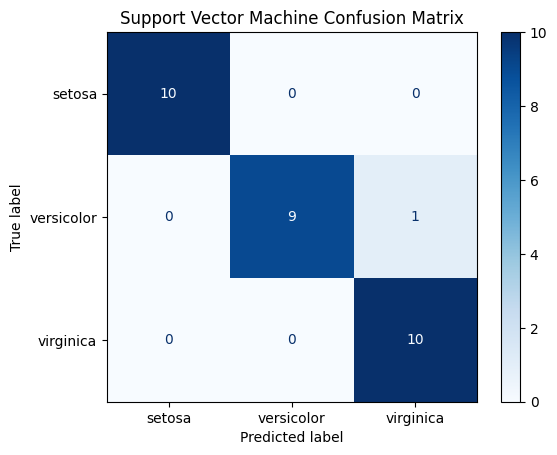

In [ ]:
# Build Support Vector Machine classifier
# RBF kernel allows nonlinear class boundaries

svm_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf")
)

svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

evaluate_model(
    "Support Vector Machine",
    y_test,
    svm_predictions
)

In [ ]:
# Convert all model results into a comparison table

comparison_df = pd.DataFrame(results).T

# Round results for readability
comparison_df = comparison_df.round(3)

# Sort models from highest to lowest F1-score
comparison_df = comparison_df.sort_values(
    by="F1-Score",
    ascending=False
)

print("Final Model Comparison")
display(comparison_df)

Final Model Comparison


,Accuracy,Precision,Recall,F1-Score
Decision Tree,0.967,0.970,0.967,0.967
Rule-Based Classifier,0.967,0.970,0.967,0.967
Naive Bayes,0.967,0.970,0.967,0.967
Support Vector Machine,0.967,0.970,0.967,0.967
Logistic Regression,0.933,0.933,0.933,0.933
K-Nearest Neighbors,0.933,0.944,0.933,0.933
